## Цель работы

Изучить работу метода опорных векторов для решения задачи многоклассовой классификации, а именно - разработать модель машинного обучения, которая будет предсказывать уровень итоговой оценки студента (низкий, средний, высокий).

## Данные

Использовать Dataset student-mat.csv

Источник: https://archive.ics.uci.edu/dataset/320/student+performance

Данные отражают успеваемость учащихся в системе среднего образования двух школ. Данные включают оценки учащихся, демографические, социальные и связанные со школой характеристики. Были собраны с использованием школьных отчетов и анкет.

## Задание:

**1 часть - Анализ и визуализация**

+ Преобразовать целевую переменную G3 (итоговую оценку) в категориальную по принципу "низкая", "средняя", "высокая" (шкалу для каждого уровня определите самостоятельно).
+ Визуализировать количество значений преобразованной целевой переменной.
+ Визуализировать количество обучающихся в каждой категории итоговой оценки.
+ Построить диаграмму распределения по полу и уровню итоговой оценки.
+ Вычислить и численно указать корреляции между числовыми признаками (количество определите сами, но не менее 7) и целевой переменной.
+ Визуально отобразите значения корреляции.
+ Отобразите график clustermap (информация о графике - https://mipt-stats.gitlab.io/courses/python/09_seaborn.html?ysclid=lw7n8ef0x0692843331#8.-Clustermap). Чем отличается от heatmap?

---
**2 часть**

+ Работать с полным объёмом данных, со всеми признаками
+ Преобразуйте категориальные переменные в фиктивные/индикаторные переменные (Dummy variables) c помощью get_dummies (https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html).
+ Выполнить разбиение данных (обучающий набор - определить самостоятельно, обосновать), выполнить масштабирование.
+ Создать экземпляр классификатора SVC с параметрами kernel, С, degree
+ Исследовать работу метода опорных векторов при различных значениях kernel, С, degree, оценить качество полученных моделей
+ Создать новый экземпляр классификатора SVC с параметром class_weight для решения проблемы несбалансированности классов

**Заметка:**
в документации https://scikit-learn.ru/1-4-support-vector-machines/ найти, какое значение присвоить class_weight.

+ С помощью GridSearchCV выполните поиск по сетке значений параметров C и gamma.
+ Отобразить матрицу ошибок и отчет классификации
+ Насколько хорошо работает модель? Чтобы вы могли дополнительно исследовать при настройке модели/доработке датасета (делать не нужно - просто ваши мысли и рассуждения устно).

-------------

# задание 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student-mat.csv")

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


описание датасета

school — школа, в которой обучается студент

sex — пол студента

age — возраст студента

address — тип места проживания студента

famsize — размер семьи

Pstatus — семейное положение родителей

Medu — уровень образования матери

Fedu — уровень образования отца

Mjob — род занятий матери

Fjob — род занятий отца

reason — причина выбора школы

guardian — законный опекун студента

traveltime — время в пути от дома до школы

studytime — время, затрачиваемое на учебу

failures — количество предыдущих академических неудач

schoolsup — наличие дополнительной учебной поддержки от школы

famsup — наличие семейной учебной поддержки

paid — наличие дополнительных платных занятий

activities — участие во внеучебных активностях

nursery — посещение детского сада

higher — намерение продолжить обучение в высшем учебном заведении

internet — наличие доступа к интернету дома

romantic — наличие романтических отношений

famrel — качество семейных отношений

freetime — количество свободного времени после школы

goout — активность проведения времени с друзьями

Dalc — уровень потребления алкоголя в будние дни

Walc — уровень потребления алкоголя в выходные дни

health — состояние здоровья студента

absences — количество пропусков занятий

G1 — оценка за первый период обучения

G2 — оценка за второй период обучения

G3 — итоговая оценка за курс обучения (целевая переменная)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
df['G3'].max()

np.int64(20)

g3 в категории 

низкая (до 50%) 0-9

средняя (от 50% до 75$) 10–14

высокая 15–20

In [7]:
bins = [0, 9, 14, 20]
labels = ["низкая", "средняя", "высокая"]


у pd.cut() по умолчанию интервалы (a, b]

right=True (по умолчанию) 

include_lowest=True - если хотим включить самую нижнюю точку в первый интервал

In [8]:
df["G3_level"] = pd.cut(df["G3"], bins=bins, labels=labels, include_lowest=True)
df[["G3", "G3_level"]].head()

,G3,G3_level
0,6,низкая
1,6,низкая
2,10,средняя
3,15,высокая
4,10,средняя


In [9]:
df["G3_level"].value_counts()

G3_level
средняя    192
низкая     130
высокая     73
Name: count, dtype: int64

колво в каждой категории

по х категория, по у колво

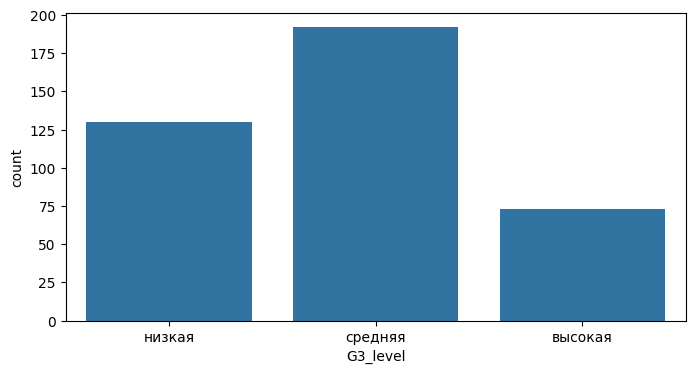

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x="G3_level", data=df)
plt.show()

распределение итоговой оценки по полу

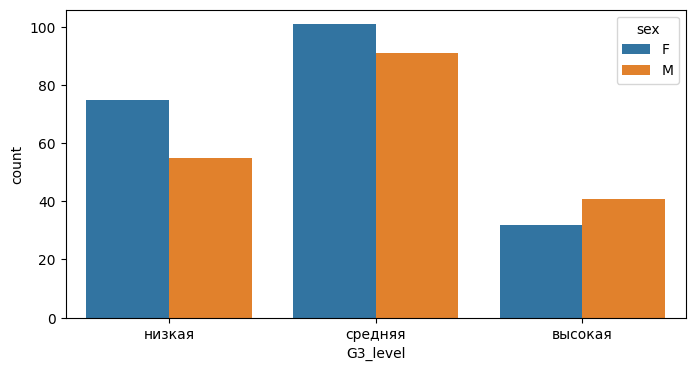

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(x="G3_level", hue="sex", data=df)
plt.show()

убираем столбец g3, тк если оставить там будет строка corr(G3, G3) = 1.0

In [12]:
corr_ind = df.corr(numeric_only=True)["G3"].drop("G3")

In [13]:
corr_ind

age          -0.161579
Medu          0.217147
Fedu          0.152457
traveltime   -0.117142
studytime     0.097820
failures     -0.360415
famrel        0.051363
freetime      0.011307
goout        -0.132791
Dalc         -0.054660
Walc         -0.051939
health       -0.061335
absences      0.034247
G1            0.801468
G2            0.904868
Name: G3, dtype: float64

берем с модулем, чтобы искать названия сильных связей, а не только положительные

In [14]:
top7_idx = corr_ind.abs().nlargest(7).index
top7 = corr_ind.loc[top7_idx]                
top7

G2          0.904868
G1          0.801468
failures   -0.360415
Medu        0.217147
age        -0.161579
Fedu        0.152457
goout      -0.132791
Name: G3, dtype: float64

для матрицы уже возрващаем g3, чтобы видеть связь признаков с целеыой

In [15]:
cols_heatmap = list(top7.index) + ["G3"]
corr_7 = df[cols_heatmap].corr(numeric_only=True)

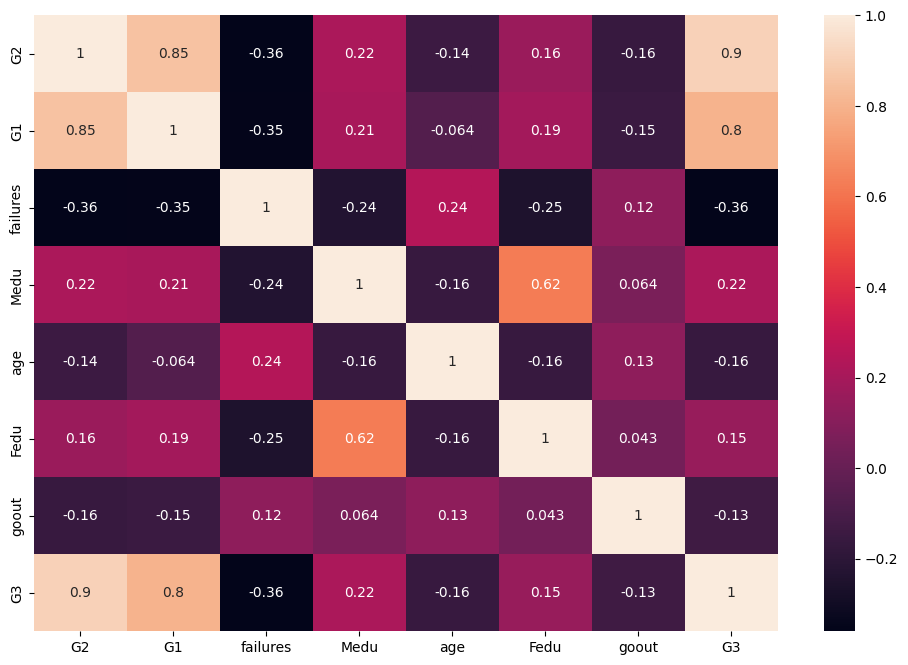

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_7, annot=True)
plt.show()


итоговая оценка G3 наиболее сильно связана с предыдущими оценками G2(0.90) и G1(0.80)

умеренная отрицательная корреляция между G3 и количеством прошлых неудач failures (−0.36) - чем больше академических провало, тем хуже итоговая оценка. 

остальные признаки имеют слабую корреляцию с G3 (ниже +-0.25) то есть оказывают менее значимое влияние

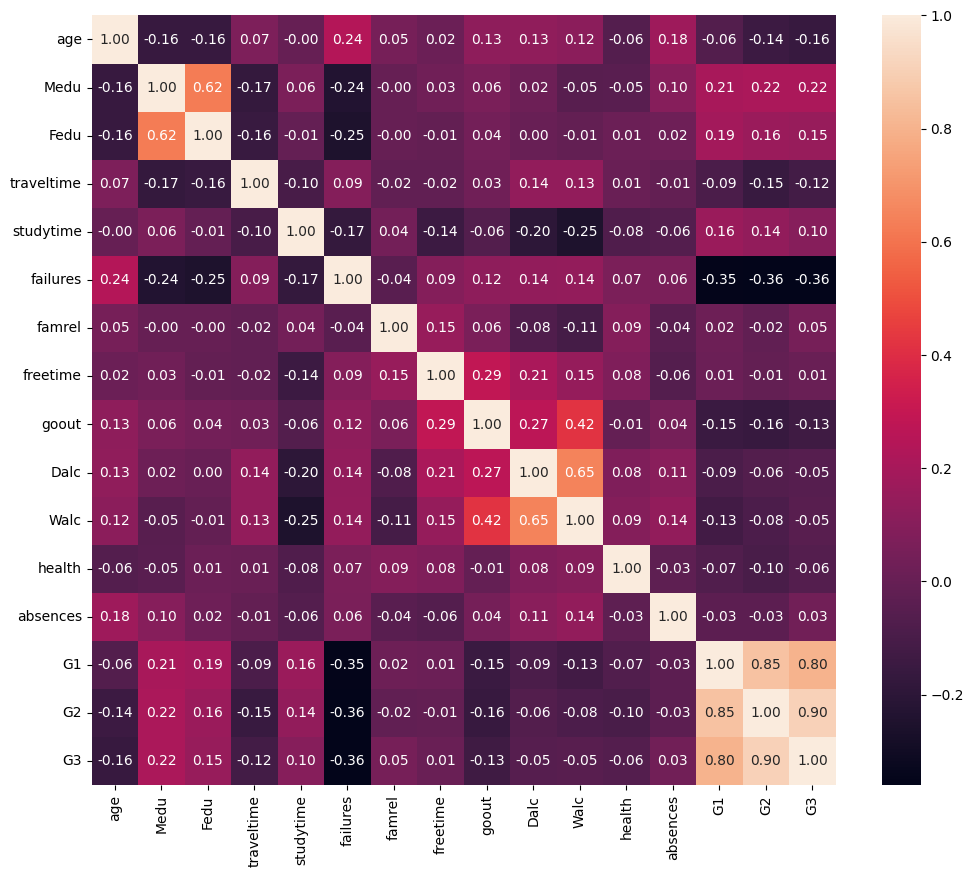

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()


clustermap строит тепловую карту + деревья кластеров и переставляет строки/столбцы, чтобы похожие признаки оказались рядом

<Figure size 1200x1000 with 0 Axes>

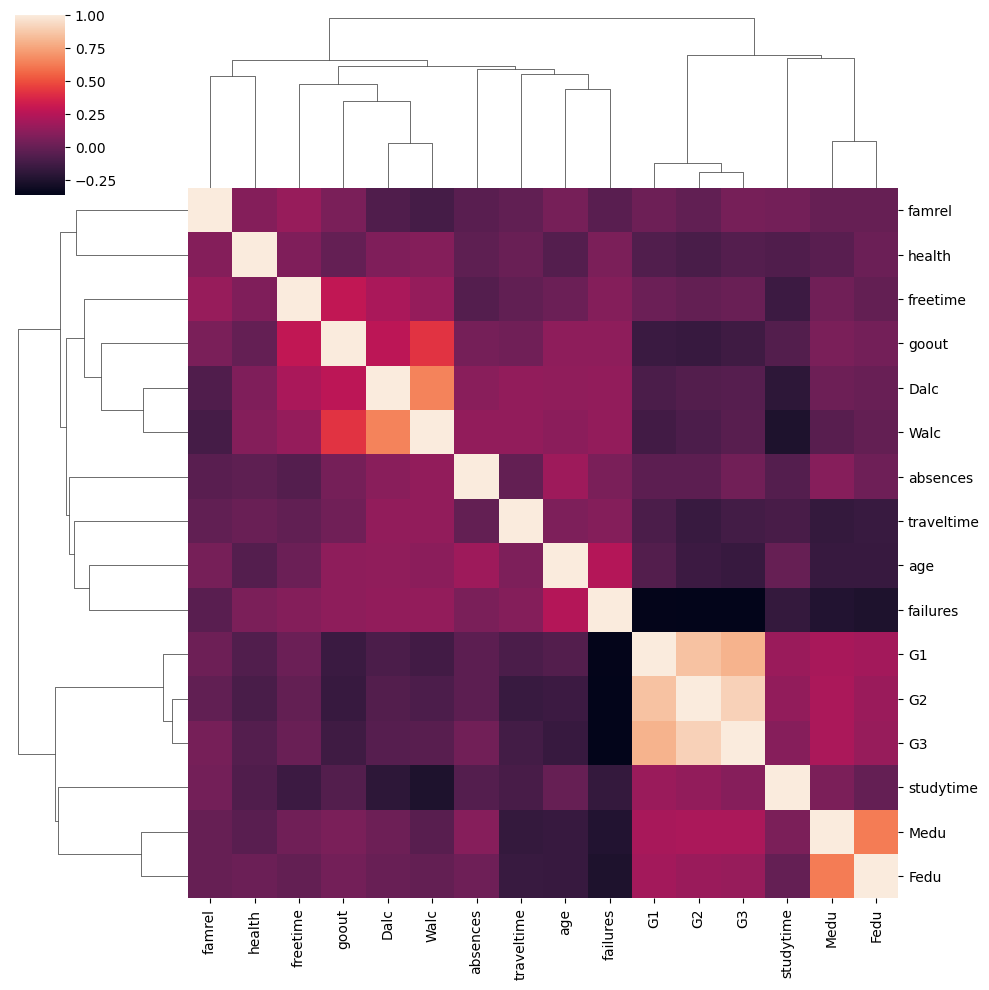

In [18]:
plt.figure(figsize=(12, 10))
sns.clustermap(df.corr(numeric_only=True))
plt.show()


деревья сверху и слева показывают какие признаки похожи по структуре связей и группируют их

самый очевидный кластер - оценки. мы видим блок с г1,г2,г3, это значит, что между ними очень высокая положительная корреляция (ученик, который хорошо учится, с высокой вероятностью хорошо сдаст итоговый экзамен)

также рядом с ними группируются фейлы (черный цвет относительно г1–г3 - отрицательная связь). это больше неудач, значит ниже оценки


потом рядом dalc, walc, goout, freetime - это про образ жизни студента. он связан внутри себя, но на оценки прямое влияние слабое

потом studytime, Medu, Fedu. studytime ближе к оценкам, чем к социальному (образование родителей и время на учебу влияют, но не так сильно, как предыдущие оценки)

блок famrel и health и блок absences, traveltime, age - они не являются ключевыми факторами успеваемости

отличие clustermap от heatmap

heatmap рисует матрицу как есть, то есть порядок строк столбцов обычно исходный

а clustermap дополнительно кластеризует строки и столбцы (иерархически) и переставляет признаки так, чтобы похожие были рядом, поэтому иногда структура видна гораздо лучше

ради интереса посмотрим еще графики

распределение оценок

21 столбец и каждому значению (0-20) будет соответствовать свой отдельный столбец

большинство студентов в средней зоне успеваемости

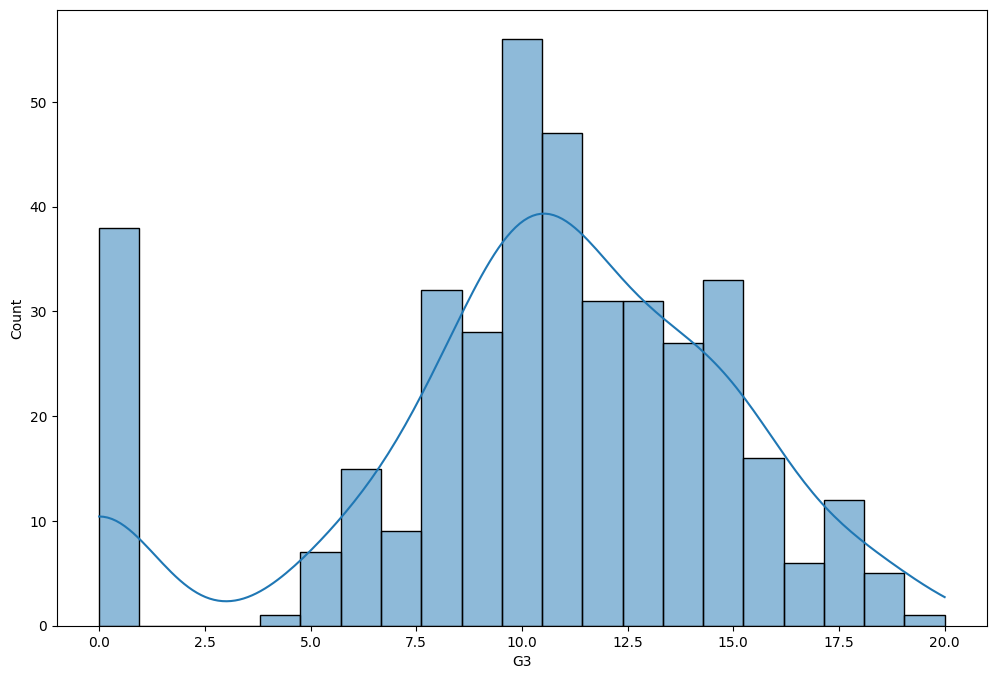

In [19]:
plt.figure(figsize=(12, 8))
sns.histplot(df["G3"], bins=21, kde=True)
plt.show()


как промежуточные оценки G1 и G2 связаны с G3

низкие значения G1 G2 в основном относятся к категории низкой итоговой оценки, а высокие значения соответствуют высокой итоговой оценке

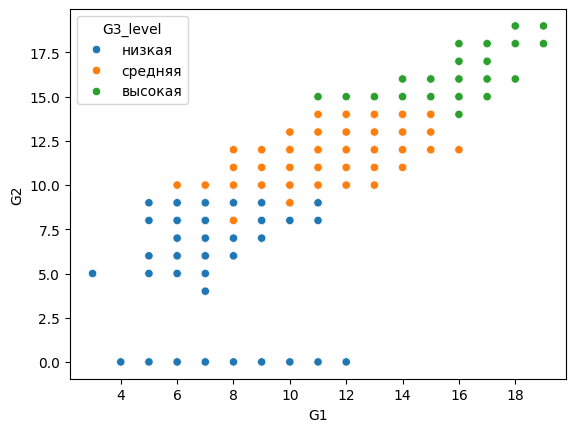

In [20]:
sns.scatterplot(x="G1", y="G2", hue="G3_level", data=df)
plt.show()

# Задание 2

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [23]:
df["G3_level"].value_counts()

G3_level
средняя    192
низкая     130
высокая     73
Name: count, dtype: int64

In [24]:
X = df.drop(["G3", "G3_level"], axis=1)
y = df["G3_level"]

категориальные признаки в dummy

In [25]:
X = pd.get_dummies(X, drop_first=True)

размеры

In [26]:
X.shape, y.shape

((395, 41), (395,))

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

масштабируем

In [28]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### перебор моделей

посмотрим точности моделей с разными ядрами (линейное, рбф и поли) С=1

линейное:

In [29]:
svc_linear = SVC(kernel="linear", C=1)
svc_linear.fit(X_train_sc, y_train)
pred_linear = svc_linear.predict(X_test_sc)
accuracy_score(y_test, pred_linear)

0.7848101265822784

рбф:

In [30]:
svc_rbf = SVC(kernel="rbf", C=1)
svc_rbf.fit(X_train_sc, y_train)
pred_rbf = svc_rbf.predict(X_test_sc)
accuracy_score(y_test, pred_rbf)


0.6582278481012658

поли с степенью 2

In [31]:
svc_poly2 = SVC(kernel="poly", C=1, degree=2)
svc_poly2.fit(X_train_sc, y_train)
pred_poly2 = svc_poly2.predict(X_test_sc)
accuracy_score(y_test, pred_poly2)

0.569620253164557

поли с степенью 3

In [32]:
svc_poly3 = SVC(kernel="poly", C=1, degree=3)
svc_poly3.fit(X_train_sc, y_train)
pred_poly3 = svc_poly3.predict(X_test_sc)
accuracy_score(y_test, pred_poly3)


0.5822784810126582

### линейная

отсюда видим, что точность лучше у линейного (78%), берем его и посмотрим с разными значениями С (0.1, 1, 10) 

In [33]:
svc_linear = SVC(kernel="linear", C=0.1)
svc_linear.fit(X_train_sc, y_train)
pred_linear = svc_linear.predict(X_test_sc)
accuracy_score(y_test, pred_linear)

0.7721518987341772

In [34]:
svc_linear = SVC(kernel="linear", C=1)
svc_linear.fit(X_train_sc, y_train)
pred_linear = svc_linear.predict(X_test_sc)
accuracy_score(y_test, pred_linear)

0.7848101265822784

In [38]:
svc_linear = SVC(kernel="linear", C=10)
svc_linear.fit(X_train_sc, y_train)
pred_linear = svc_linear.predict(X_test_sc)
accuracy_score(y_test, pred_linear)

0.7974683544303798

видим, что точность выше при С=10 (79,7%)

class_weight перераспределяет внимание модели между классами, чтобы редкие классы не игнорировались

In [68]:
svc_linear_class = SVC(kernel="linear", C=10, class_weight="balanced")
svc_linear_class.fit(X_train_sc, y_train)
pred_linear_class = svc_linear_class.predict(X_test_sc)
accuracy_score(y_test, pred_linear_class)

0.7974683544303798

Матрица ошибок

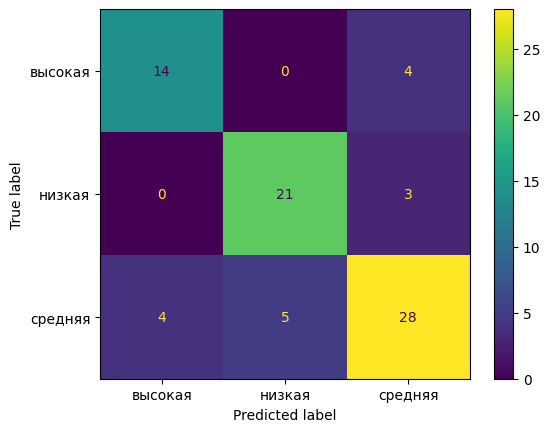

In [65]:
ConfusionMatrixDisplay.from_estimator(svc_linear_class, X_test_sc, y_test)
plt.show()

По матрице

Высокая
14 из 18 - правильно

Низкая
21 из 24 - правильно

Средняя
28 из 37 — правильно

Вывод линейная модель очень стабильна, лучше всего распознаёт "низкую", а "средняя" самый сложный класс

In [41]:
print(classification_report(y_test, pred_linear_class))

              precision    recall  f1-score   support

     высокая       0.78      0.78      0.78        18
      низкая       0.81      0.88      0.84        24
     средняя       0.80      0.76      0.78        37

    accuracy                           0.80        79
   macro avg       0.80      0.80      0.80        79
weighted avg       0.80      0.80      0.80        79



accuracy = 0.80

macro avg f1 = 0.80

классы сбалансированы по метрикам - это хорошая устойчивая модель

### rbf с grid

С помощью GridSearchCV поиск по сетке значений параметров C и gamma

rbf - radial basis function обучение модели с рбф предполагает наличие двух параметров: С и gamma

In [49]:
from sklearn.model_selection import GridSearchCV

In [53]:
svc_rbf_class = SVC(kernel="rbf", class_weight="balanced")
param_grid = {"C": [0.1, 1, 10],"gamma": [0.01, 0.1, 1]} #набор параметров
grid = GridSearchCV(svc_rbf_class, param_grid=param_grid)

In [55]:
grid.fit(X_train_sc, y_train)

,estimator,SVC(class_weight='balanced')
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [56]:
grid.best_params_

{'C': 10, 'gamma': 0.01}

In [58]:
best_model = grid.best_estimator_

In [59]:
y_pred = best_model.predict(X_test_sc)

In [60]:
accuracy_score(y_test, y_pred)

0.7468354430379747

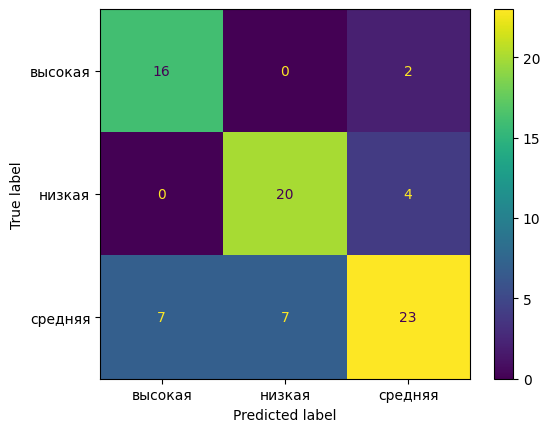

In [62]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test_sc, y_test)
plt.show()


По матрице

Высокая
16 из 18 - правильно

Низкая
20 из 24 - немного хуже, чем у линейной

Средняя
только 23 из 37 — заметно хуже

Вывод хуже справляется со средней категорией, общая стабильность ниже

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     высокая       0.70      0.89      0.78        18
      низкая       0.74      0.83      0.78        24
     средняя       0.79      0.62      0.70        37

    accuracy                           0.75        79
   macro avg       0.74      0.78      0.75        79
weighted avg       0.75      0.75      0.74        79



accuracy = 0.75

macro avg f1 = 0.75

recall у средней=0.62 слабое место

модель менее устойчива, хуже разделяет среднюю оценку

# проверки

## реальные

берем из датасета

GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15

In [70]:
new_student = pd.DataFrame({
    'school': ['GP'],
    'sex': ['F'],
    'age': [15],
    'address': ['U'],
    'famsize': ['GT3'],
    'Pstatus': ['T'],
    'Medu': [4],
    'Fedu': [2],
    'Mjob': ['health'],
    'Fjob': ['services'],
    'reason': ['home'],
    'guardian': ['mother'],
    'traveltime': [1],
    'studytime': [3],
    'failures': [0],
    'schoolsup': ['no'],
    'famsup': ['yes'],
    'paid': ['yes'],
    'activities': ['yes'],
    'nursery': ['yes'],
    'higher': ['yes'],
    'internet': ['yes'],
    'romantic': ['yes'],
    'famrel': [3],
    'freetime': [2],
    'goout': [2],
    'Dalc': [1],
    'Walc': [1],
    'health': [5],
    'absences': [2],
    'G1': [15],
    'G2': [14]
})

In [71]:
new_student_enc = pd.get_dummies(new_student, drop_first=True)
new_student_enc = new_student_enc.reindex(columns=X.columns, fill_value=0)

In [72]:
new_student_sc = scaler.transform(new_student_enc)

In [75]:
print("линейная:", svc_linear_class.predict(new_student_sc)[0])
print("рбф с грид:", best_model.predict(new_student_sc)[0])

линейная: высокая
рбф с грид: средняя


в исходном g3=15 - это высокая

здесь видим, что линейная правильно попала

## плохие

In [104]:
bad_student = pd.DataFrame({
    'school': ['GP'],
    'sex': ['M'],
    'age': [17],
    'address': ['U'],
    'famsize': ['GT3'],
    'Pstatus': ['A'],
    'Medu': [1],
    'Fedu': [1],
    'Mjob': ['other'],
    'Fjob': ['other'],
    'reason': ['course'],
    'guardian': ['mother'],
    'traveltime': [3],
    'studytime': [1], 
    'failures': [3],
    'schoolsup': ['yes'],
    'famsup': ['no'],
    'paid': ['no'],
    'activities': ['no'],
    'nursery': ['no'],
    'higher': ['yes'],
    'internet': ['yes'],
    'romantic': ['yes'],
    'famrel': [2],
    'freetime': [4],
    'goout': [4],
    'Dalc': [3],
    'Walc': [4],
    'health': [3],
    'absences': [25],
    'G1': [12],
    'G2': [6]
})


здесь противоречивые данные, вероятно 1 модель скажет средняя, а другая низкая (не получилось подобрать так)

studytime': [1] - мало учится

'failures': [3], - много неудач

'absences': [25],- много пропусков

'G1': [12], -  неплохо

'G2': [6] - плохо

In [105]:
bad_enc = pd.get_dummies(bad_student, drop_first=True)
bad_enc = bad_enc.reindex(columns=X.columns, fill_value=0)


In [106]:
bad_sc = scaler.transform(bad_enc)

In [107]:
print("линейная:", svc_linear_class.predict(bad_sc)[0])
print("рбф с грид::", best_model.predict(bad_sc)[0])

линейная: средняя
рбф с грид:: средняя
